In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror{font-family:Consolas; font-size:15pt;}
div.output{font-size:12pt; font-weight:bold;}
div.input{font-family:Consolas; font-size:12pt;}
div.prompt{min-width:70px;}
div#toc-wrapper {padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

# 1. 데이터 생성
- 남자, 여자의 키와 몸무게 데이터를 군집화

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt

In [5]:
random.randint(40,95) # 40부터 95까지의 정수 중 하나를 무작위 선택 반환

43

In [9]:
data = []
for i in range(50):
    # 여자 데이터
    data.append([random.randint(40,70), random.randint(140,170)])
    # 남자 데이터
    data.append([random.randint(60,95), random.randint(160,195)])
# data

In [13]:
# 여자
for femaie in data[:100:2]:
    print(femaie, end='')
# 남자
print('\n-------------------')
for male in data[1:100:2]:
    print(male, end='')

[63, 146][58, 143][66, 160][48, 165][49, 150][58, 164][42, 145][44, 158][50, 169][57, 163][46, 144][67, 143][40, 150][45, 166][56, 163][52, 164][41, 154][67, 142][41, 141][56, 162][70, 158][49, 155][55, 147][41, 155][69, 155][42, 168][46, 157][48, 155][61, 167][66, 169][40, 149][60, 143][41, 144][42, 155][54, 164][46, 144][70, 142][70, 153][50, 155][69, 162][63, 166][40, 168][63, 159][61, 159][42, 153][42, 162][50, 152][65, 157][55, 159][49, 144]
-------------------
[69, 187][75, 174][80, 188][78, 178][87, 184][75, 163][71, 174][72, 195][88, 174][62, 172][70, 168][83, 174][60, 178][78, 189][90, 174][93, 162][88, 195][63, 162][91, 182][64, 194][69, 184][87, 180][89, 175][60, 160][67, 188][68, 192][71, 164][88, 195][95, 162][75, 195][64, 189][79, 182][81, 179][70, 167][89, 162][60, 186][75, 174][82, 174][69, 186][80, 175][63, 171][71, 175][66, 166][73, 166][85, 189][91, 192][87, 174][66, 185][72, 192][74, 179]

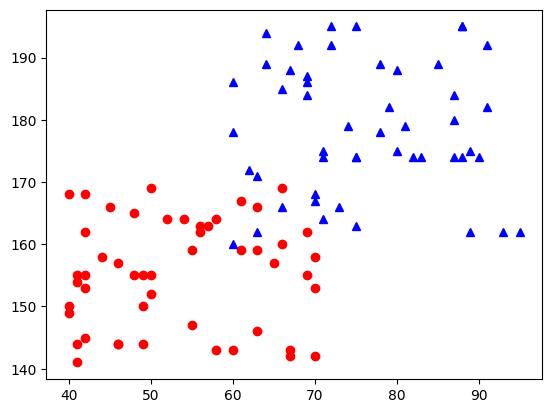

In [18]:
# print('여자 몸무게 :',[d[0] for d in data[::2]])
# print('여자 키 :',[d[1] for d in data[::2]])
# print('남자 몸무게 :',[d[0] for d in data[1::2]])
# print('남자 키 :',[d[1] for d in data[1::2]])
plt.plot([d[0] for d in data[::2]],
         [d[1] for d in data[::2]], 'o', color='r')
plt.plot([d[0] for d in data[1::2]],
         [d[1] for d in data[1::2]], '^', color='b')

# 2. 군집화 로직

In [19]:
# 초기 랜덤지점 2개
random_points = [[random.randint(40, 95), random.randint(140, 195)],
                 [random.randint(40, 95), random.randint(140, 195)]]
random_points

[[68, 187], [59, 156]]

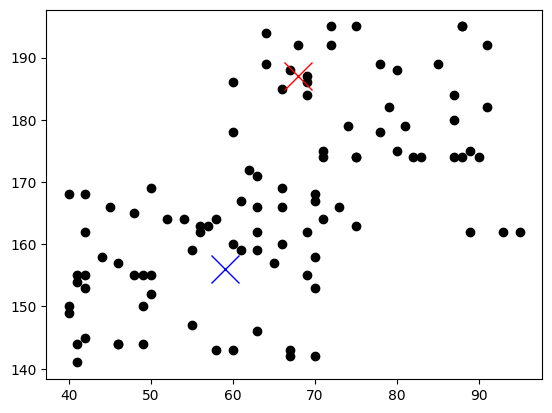

In [22]:
plt.plot([d[0] for d in data],
         [d[1] for d in data], 'o', color='k')
plt.plot(random_points[0][0],
         random_points[0][1], 'x', color='r', markersize=20) # 기준점1
plt.plot(random_points[1][0],
         random_points[1][1], 'x', color='b', markersize=20) # 기준점2

In [23]:
# 두 점의 거리를 return a:(0,0) ~ b:(4,3)
def dist(a, b):
    return np.sqrt( (a[0]-b[0])**2 + (a[1]-b[1])**2 )

In [25]:
a = [1, 0]; b = [4, 3]
dist(a, b)

4.242640687119285

In [26]:
# random_points[0]과 random_points[1]을 기준으로 나눈 두 영역
group1 = [] # random_points[0]이 가까운 그룹
group2 = [] # random_points[1]이 가까운 그룹
for d in data:
    if dist(random_points[0], d) < dist(random_points[1], d):
        group1.append(d) # 빨간 X랑 더 가까운 그룹
    else:
        group2.append(d) # 파란 X랑 더 가까운 그룹
len(group1), len(group2)

(38, 62)

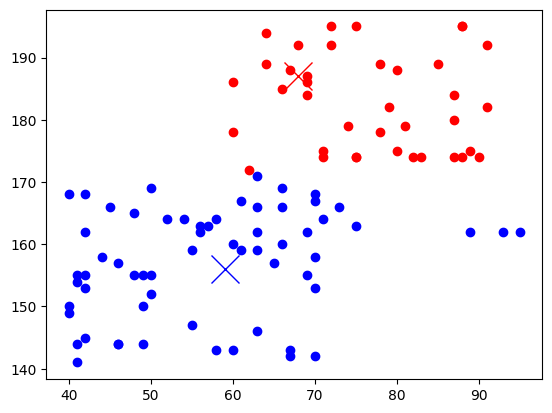

In [29]:
# 새로운 그룹 group1과 group2, 초기 랜덤 지점
plt.plot([d[0] for d in group1],
         [d[1] for d in group1], 'o', color='r')
plt.plot([d[0] for d in group2],
         [d[1] for d in group2], 'o', color='b')
plt.plot(random_points[0][0],
         random_points[0][1], 'x', color='r', markersize=20) # 기준점1
plt.plot(random_points[1][0],
         random_points[1][1], 'x', color='b', markersize=20) # 기준점2
plt.show()

In [30]:
# 기준점 이동 group1이 중심점, group2의 중심점
sumX = 0; sumY = 0
for g in group1:
    sumX += g[0]
    sumY += g[1]
# 새로운 기준점으로 할당
random_points[0] = [sumX/len(group1), sumY/len(group1)]

sumX = 0; sumY = 0
for g in group2:
    sumX += g[0]
    sumY += g[1]
# 새로운 기준점으로 할당
random_points[1] = [sumX/len(group2), sumY/len(group2)]
random_points

[[76.71052631578948, 182.94736842105263],
 [57.306451612903224, 157.11290322580646]]

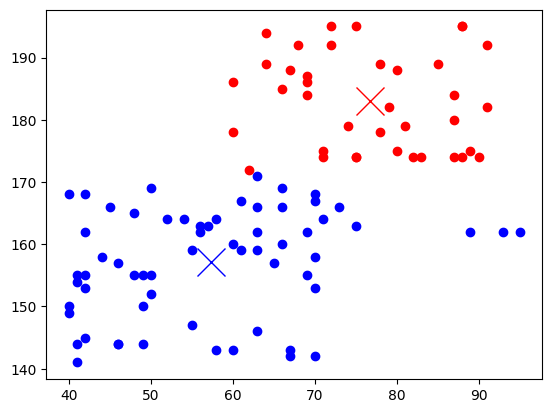

In [31]:
plt.plot([d[0] for d in group1],
         [d[1] for d in group1], 'o', color='r')
plt.plot([d[0] for d in group2],
         [d[1] for d in group2], 'o', color='b')
plt.plot(random_points[0][0],
         random_points[0][1], 'x', color='r', markersize=20) # 기준점1
plt.plot(random_points[1][0],
         random_points[1][1], 'x', color='b', markersize=20) # 기준점2
plt.show()

# 3. 전체 코드(for문이용)
- data 생성
- 랜덤포인트 2지점 임의로 만들기
- for문
    - 랜덤포인트 2지점 기준으로 group1과 group2
    - 랜덤포인트 이용(group1중간점, group2중간점)

초기 points :  [[88, 157], [57, 180]]
1 번째 points :  [[78.0, 166.66666666666666], [60.622950819672134, 166.9672131147541]]
2 번째 points :  [[80.62222222222222, 176.9777777777778], [56.58181818181818, 158.56363636363636]]
3 번째 points :  [[79.375, 178.875], [56.34615384615385, 155.75]]
4 번째 points :  [[79.375, 178.875], [56.34615384615385, 155.75]]
5 번째 points :  [[79.375, 178.875], [56.34615384615385, 155.75]]
6 번째 points :  [[79.375, 178.875], [56.34615384615385, 155.75]]
7 번째 points :  [[79.375, 178.875], [56.34615384615385, 155.75]]
8 번째 points :  [[79.375, 178.875], [56.34615384615385, 155.75]]
9 번째 points :  [[79.375, 178.875], [56.34615384615385, 155.75]]
10 번째 points :  [[79.375, 178.875], [56.34615384615385, 155.75]]


(140.0, 195.0)

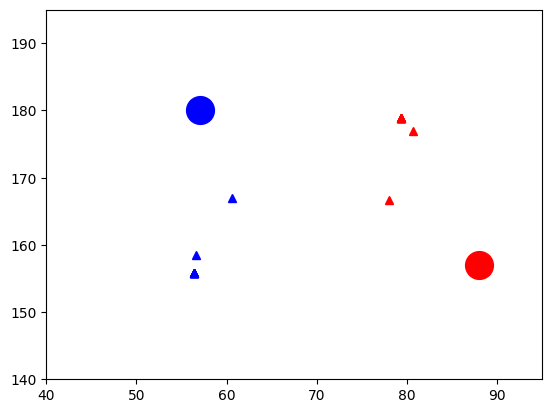

In [38]:
# 데이터 생성
data = []
for i in range(50):
    # 여자 데이터
    data.append([random.randint(40,70), random.randint(140,170)])
    # 남자 데이터
    data.append([random.randint(60,95), random.randint(160,195)])
    
# point 지정
points = [[random.randint(40, 95), random.randint(140, 195)],
          [random.randint(40, 95), random.randint(140, 195)]]

print('초기 points : ', points)
plt.plot(points[0][0], points[0][1], 'o', c='r', markersize=20)
plt.plot(points[1][0], points[1][1], 'o', c='b', markersize=20)
# 포인트 2지점 기준으로 group1과 group2
for i in range(1, 11):
    group1 = [] # points[0]과 가까운 그룹
    group2 = [] # points[1]과 가까운 그룹
    for d in data:
        if dist(d, points[0]) < dist(d, points[1]):
            group1.append(d)
        else:
            group2.append(d)
    # 새로운 포인트로 할당
    sumX = 0; sumY = 0
    for g in group1:
        sumX += g[0]
        sumY += g[1]
    points[0] = [sumX/len(group1), sumY/len(group1)]
    sumX = 0; sumY = 0
    for g in group2:
        sumX += g[0]
        sumY += g[1]
    points[1] = [sumX/len(group2), sumY/len(group2)]
    print(i, '번째 points : ', points)
    plt.plot(points[0][0], points[0][1], '^', c='r')
    plt.plot(points[1][0], points[1][1], '^', c='b')
plt.xlim([40,95])
plt.ylim([140,195])

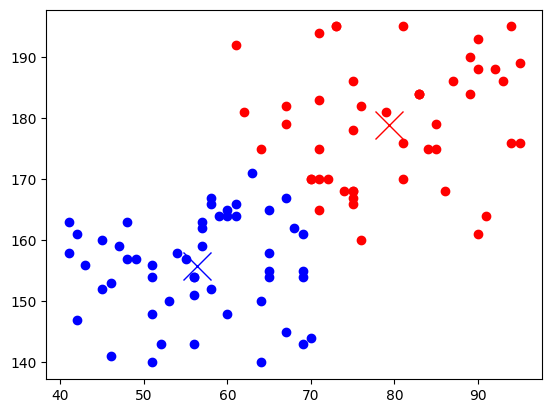

In [40]:
plt.plot([d[0] for d in group1],
         [d[1] for d in group1], 'o', color='r')
plt.plot([d[0] for d in group2],
         [d[1] for d in group2], 'o', color='b')
plt.plot(points[0][0], points[0][1], 'x', color='r', markersize=20)
plt.plot(points[1][0], points[1][1], 'x', color='b', markersize=20)

# 4. api(sklearn)를 이용한 군집화
- sklearn 머신러닝 패키지
    * 예측모델
        : 분류, 회귀, 군집분석
        fit(학습), predict(예측)
    * 변환모델
        : 전처리 ex) 스케일조정
        fit(학습), transform(변환함수)

In [42]:
# 군집분석 라이브러리가 joblib충돌 경고 메세지 출력
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [48]:
data = np.array(data)
from sklearn.cluster import KMeans
model = KMeans(n_clusters=2, # 2개 그룹으로 나눠
               init='random', # 초기 중심점 랜덤하게
               n_init=10, # 10번 실행
               random_state=7)
model.fit(data)

KMeans(init='random', n_clusters=2, n_init=10, random_state=7)

In [49]:
# 중심점
model.cluster_centers_

array([[ 79.375     , 178.875     ],
       [ 56.34615385, 155.75      ]])

In [50]:
# 나눠진 그룹들의 인덱스
model.labels_

array([1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0])

In [53]:
group1 = data[model.labels_==1]
group2 = data[model.labels_==0]
c1, c2 = model.cluster_centers_

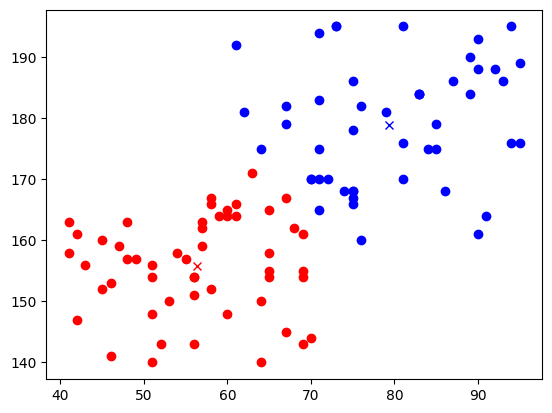

In [55]:
plt.plot([d[0] for d in group1],
         [d[1] for d in group1], 'o', color='r')
plt.plot([d[0] for d in group2],
         [d[1] for d in group2], 'o', color='b')
plt.plot(c1[0], c1[1], 'x', color='b') # group2의 중심점
plt.plot(c2[0], c2[1], 'x', color='r') # group1의 중심점